# Notebook 08 — Transformer Model (Simplified TFT)

**Goal**: Train a Simplified Temporal Fusion Transformer for multi-horizon prediction.

---

## Why Transformers for Time Series?

The **attention mechanism** lets the model dynamically weight which historical days
matter most for predicting the future:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Unlike LSTM which processes sequentially, attention can directly relate
today's features to events 30 days ago — useful for catching earnings
jumps, sector rotations, and macro events.

## Our Architecture: Simplified TFT

The full Temporal Fusion Transformer (Bryan Lim, 2019) is complex.
Our simplified version keeps the key innovations:

1. **Gated Residual Networks (GRN)**: Adaptive feature processing
2. **LSTM encoder**: Capture local temporal dynamics
3. **Multi-head attention**: Focus on important time steps
4. **Multi-horizon output**: Predict 1, 5, 10, 20 day returns simultaneously

### Architecture Diagram

```
Input (60 days × features)
        │
   [GRN Layer]  ← Feature-level gating
        │
   [LSTM Encoder] ← Local temporal patterns
        │
   [Multi-Head Attention] ← Global temporal attention
        │
   [Feed-Forward]
        │
   [Output: 4 horizons] → ret_1d, ret_5d, ret_10d, ret_20d
```

### Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Sequence length | 60 days | Longer context for attention |
| Hidden size | 64 | Smaller than LSTM (attention is efficient) |
| Attention heads | 4 | Multi-view attention |
| LSTM layers | 1 | Pre-attention encoding |
| Dropout | 0.2 | Lighter regularization |

In [ ]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, accuracy_score

from src.backtest import WalkForwardCV
from src.models import TransformerModel
from src.features import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"✅ Setup complete | Device: {device}")

✅ Setup complete | Device: mps


## Step 1 — Load Data

In [ ]:
# Load processed data
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.NS.parquet"))
processed_files = [f for f in processed_files if "prediction" not in f.stem]

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

# Use ALL tickers to match XGBoost/LightGBM for ensemble alignment
sample_tickers = list(all_data.keys())

pipeline = FeaturePipeline()
target_horizon = 5

# Load clip_target from config (reduces sensitivity to outlier returns)
import yaml
with open(str(CONFIG_DIR / "model_params.yaml")) as _f:
    _model_cfg = yaml.safe_load(_f)
clip_target = _model_cfg.get("transformer", {}).get("clip_target", 0.03)
print(f"Target clipping: ±{clip_target:.0%}")

all_rows = []
for ticker in sample_tickers:
    df = all_data[ticker]
    feature_cols = pipeline.get_feature_columns(df)
    target = df["Close"].pct_change(target_horizon).shift(-target_horizon)
    # Clip extreme returns to reduce outlier sensitivity
    target = target.clip(-clip_target, clip_target)
    valid = target.dropna().index.intersection(df.dropna(subset=feature_cols).index)

    if len(valid) > 200:
        chunk = df.loc[valid, feature_cols].copy()
        chunk["_date"] = chunk.index
        chunk["_ticker"] = ticker
        chunk["_target"] = target.loc[valid].values
        all_rows.append(chunk)

# Replace inf/-inf with NaN, then fill remaining NaN with 0
panel = pd.concat(all_rows, ignore_index=True)
panel = panel.replace([np.inf, -np.inf], np.nan).fillna(0)
panel = panel.sort_values(["_ticker", "_date"]).reset_index(drop=True)

feature_cols = [c for c in panel.columns if c not in ("_date", "_ticker", "_target")]
X_all = panel[feature_cols]
y_all = panel["_target"]

print(f"Samples: {len(X_all):,}  Features: {len(feature_cols)}")
print(f"Tickers used: {panel['_ticker'].nunique()}")
print(f"Target range: [{y_all.min():.4f}, {y_all.max():.4f}] (clipped to ±{clip_target:.0%})")

Target clipping: ±3%
Samples: 246,508  Features: 206
Tickers used: 121
Target range: [-0.0300, 0.0300] (clipped to ±3%)


## Step 2 — Walk-Forward Training

In [ ]:
# Date-based walk-forward parameters (EXPANDING WINDOW)
train_days = 504
test_days = 63
embargo_days = 5
step_days = 63

model = TransformerModel(task="regression")

unique_dates = np.sort(panel["_date"].unique())
n_dates = len(unique_dates)

fold_results = []
fold_predictions = []
fold_num = 0

start = 0
while start + train_days + embargo_days + test_days <= n_dates:
    fold_num += 1

    train_end = start + train_days
    test_start = train_end + embargo_days
    test_end = min(test_start + test_days, n_dates)

    # EXPANDING WINDOW: always start training from date 0
    train_dates = unique_dates[0:train_end]
    test_dates = unique_dates[test_start:test_end]

    # Split validation from end of training period (~50 trading days)
    val_split = max(0, len(train_dates) - 50)
    val_date_set = set(train_dates[val_split:])

    train_fit_mask = panel["_date"].isin(train_dates) & ~panel["_date"].isin(val_date_set)
    val_mask = panel["_date"].isin(val_date_set)
    test_mask = panel["_date"].isin(test_dates)

    X_train = X_all.loc[train_fit_mask]
    y_train = y_all.loc[train_fit_mask]
    X_val = X_all.loc[val_mask]
    y_val = y_all.loc[val_mask]
    X_test = X_all.loc[test_mask]
    y_test = y_all.loc[test_mask]

    if len(X_train) < 200 or len(X_test) < 10:
        print(f"  Skipping fold {fold_num} (insufficient data)")
        start += step_days
        continue

    t0 = pd.Timestamp(train_dates[0]).strftime("%Y-%m-%d")
    t1 = pd.Timestamp(train_dates[-1]).strftime("%Y-%m-%d")
    t2 = pd.Timestamp(test_dates[0]).strftime("%Y-%m-%d")
    t3 = pd.Timestamp(test_dates[-1]).strftime("%Y-%m-%d")
    print(f"\n--- Fold {fold_num} | Train: {t0} → {t1} | Test: {t2} → {t3} ---")

    # Train Transformer with validation for early stopping
    model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    y_pred_all = model.predict(X_test)

    # Single target → model has 1 output head; always use index 0
    if y_pred_all.ndim == 2:
        y_pred = y_pred_all[:, 0]
    else:
        y_pred = y_pred_all

    # Transformer returns fewer predictions due to seq_len window
    n_pred = len(y_pred)
    y_test_aligned = y_test.iloc[model.seq_len - 1:]
    if len(y_test_aligned) > n_pred:
        y_test_aligned = y_test_aligned.iloc[:n_pred]
    elif n_pred > len(y_test_aligned):
        y_pred = y_pred[:len(y_test_aligned)]

    rmse = np.sqrt(mean_squared_error(y_test_aligned, y_pred))
    direction_acc = accuracy_score(y_test_aligned > 0, y_pred > 0)

    fold_results.append({
        "fold": fold_num, "rmse": rmse, "direction_accuracy": direction_acc,
    })
    # Capture date and ticker for ensemble alignment
    test_idx = y_test_aligned.index
    fold_predictions.append(pd.DataFrame({
        "actual": y_test_aligned.values, "predicted": y_pred, "fold": fold_num,
        "Date": panel.loc[test_idx, "_date"].values,
        "Ticker": panel.loc[test_idx, "_ticker"].values,
    }, index=test_idx))

    print(f"  RMSE: {rmse:.4f}  Dir Acc: {direction_acc:.1%}  Predictions: {n_pred}")

    start += step_days

if fold_results:

    results_df = pd.DataFrame(fold_results)

    print(f"\n{'='*60}")

    print(f"AVERAGE: RMSE={results_df['rmse'].mean():.4f}  "          f"Dir Acc={results_df['direction_accuracy'].mean():.1%}")


--- Fold 1 | Train: 2017-03-03 → 2019-03-15 | Test: 2019-03-26 → 2019-06-28 ---
  RMSE: 0.0264  Dir Acc: 49.8%  Predictions: 6669

--- Fold 2 | Train: 2017-03-03 → 2019-06-21 | Test: 2019-07-01 → 2019-10-01 ---
  RMSE: 0.0255  Dir Acc: 49.2%  Predictions: 6754

--- Fold 3 | Train: 2017-03-03 → 2019-09-24 | Test: 2019-10-03 → 2020-01-03 ---
  RMSE: 0.0256  Dir Acc: 48.1%  Predictions: 6760

--- Fold 4 | Train: 2017-03-03 → 2019-12-27 | Test: 2020-01-06 → 2020-04-07 ---
  RMSE: 0.0279  Dir Acc: 44.8%  Predictions: 6760

--- Fold 5 | Train: 2017-03-03 → 2020-03-27 | Test: 2020-04-08 → 2020-07-09 ---
  RMSE: 0.0261  Dir Acc: 54.3%  Predictions: 6849

--- Fold 6 | Train: 2017-03-03 → 2020-07-02 | Test: 2020-07-10 → 2020-10-07 ---
  RMSE: 0.0263  Dir Acc: 48.6%  Predictions: 6940

--- Fold 7 | Train: 2017-03-03 → 2020-09-29 | Test: 2020-10-08 → 2021-01-06 ---
  RMSE: 0.0268  Dir Acc: 42.3%  Predictions: 6949

--- Fold 8 | Train: 2017-03-03 → 2020-12-30 | Test: 2021-01-07 → 2021-04-09 ---
  

## Step 3 — Attention Weight Visualization

The attention mechanism reveals **which historical days** the model focuses on
when making predictions. This is a unique advantage of transformers.

Attention weights shape: (56, 45, 45)


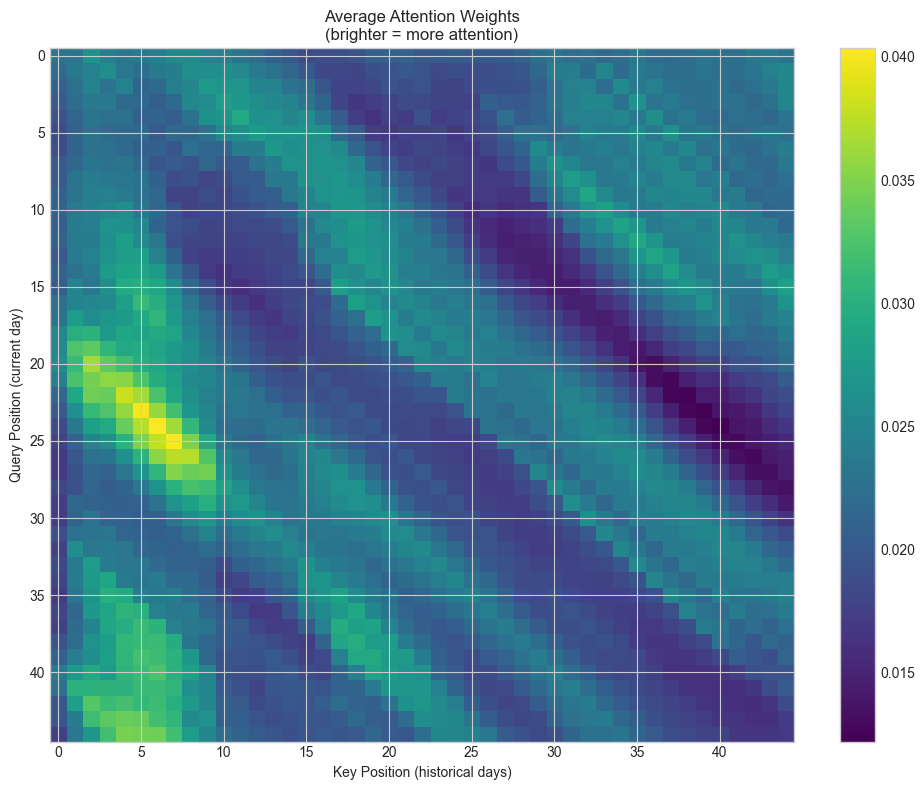

In [ ]:
# Extract attention weights from last forward pass
if hasattr(model, 'get_attention_weights'):
    try:
        # Run a forward pass on recent data to populate attention weights
        _ = model.predict(X_test.iloc[-100:])
        attn_weights = model.get_attention_weights()
        if attn_weights is not None:
            print(f"Attention weights shape: {attn_weights.shape}")
            # attn_weights shape: (batch, num_heads, seq_len, seq_len)
            if attn_weights.ndim == 4:
                avg_attn = attn_weights.mean(axis=(0, 1))  # (seq_len, seq_len)
            elif attn_weights.ndim == 3:
                avg_attn = attn_weights.mean(axis=0)  # (seq_len, seq_len)
            elif attn_weights.ndim == 2:
                avg_attn = attn_weights
            else:
                # 1D — plot as bar chart instead
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.bar(range(len(attn_weights)), attn_weights)
                ax.set_xlabel("Time Step")
                ax.set_ylabel("Attention Weight")
                ax.set_title("Average Attention Weights per Time Step")
                plt.tight_layout()
                plt.savefig(REPORTS_DIR / "transformer_attention.png", dpi=150, bbox_inches="tight")
                plt.show()
                avg_attn = None

            if avg_attn is not None and avg_attn.ndim == 2:
                fig, ax = plt.subplots(figsize=(10, 8))
                im = ax.imshow(avg_attn, cmap="viridis", aspect="auto")
                ax.set_xlabel("Key Position (historical days)")
                ax.set_ylabel("Query Position (current day)")
                ax.set_title("Average Attention Weights\n(brighter = more attention)")
                plt.colorbar(im, ax=ax)
                plt.tight_layout()
                plt.savefig(REPORTS_DIR / "transformer_attention.png", dpi=150, bbox_inches="tight")
                plt.show()
        else:
            print("No attention weights available")
    except Exception as e:
        print(f"Attention visualization skipped: {e}")
else:
    print("Attention weight extraction not available for this model")

## Step 4 — Save Model & Predictions

In [ ]:
model.save(MODELS_DIR / "transformer_model.pt")
print(f"✅ Transformer model saved")

if fold_predictions:
    preds_df = pd.concat(fold_predictions).reset_index(drop=True)
    preds_df.to_parquet(DATA_DIR / "processed" / "transformer_predictions.parquet")

    print(f"✅ Predictions saved: {len(preds_df):,} rows, {preds_df['Ticker'].nunique()} tickers")
    print(f"   Columns: {list(preds_df.columns)}")

✅ Transformer model saved
✅ Predictions saved: 187,313 rows, 121 tickers
   Columns: ['actual', 'predicted', 'fold', 'Date', 'Ticker']


## ✅ Transformer Training Complete!

**Key differences from tree models:**
- Attention mechanism provides interpretable temporal weights
- Multi-horizon output predicts multiple timeframes at once
- Higher computational cost but potentially captures complex temporal dynamics

**Next:** Proceed to **Notebook 09 — Ensemble & Stacking**

---
*Educational project. Not financial advice.*